Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

Для этого вам нужно:

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

В рамках исследования необходимо:

Исследовать датасет и определить, какой вид заказа будет учитываться в retention

Построить месячный retention

Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)

Найти когорту с самым высоким retention на 3-й месяц.

In [1]:
#Импорт и чтение(также преобразуем дату и время в datetime)
import numpy as np
import pandas as pd
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv',
                  parse_dates=["order_purchase_timestamp",      
                               "order_approved_at",
                               "order_delivered_carrier_date",
                               "order_delivered_customer_date",
                               "order_estimated_delivery_date"])                
items = pd.read_csv('olist_order_items_dataset.csv',
                  parse_dates=["shipping_limit_date"])

Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

In [3]:
# Объединяем заказы с клиентами
data = pd.merge(orders, customers, on="customer_id", how="left")

# Оставляем только доставленные заказы (игнорируем отмененные)
data = data[data["order_status"] == "delivered"]

In [4]:
# Для каждого пользователя находим дату первого заказа
first_purchase = data.groupby("customer_unique_id")["order_purchase_timestamp"].min().reset_index()
first_purchase.columns = ["customer_unique_id", "first_order_date"]

# Добавляем месяц когорты (например, "2023-01")
first_purchase["cohort_month"] = first_purchase["first_order_date"].dt.to_period("M")

# Объединяем с основными данными
data = pd.merge(data, first_purchase, on="customer_unique_id", how="left")

In [5]:
# Разница в днях между заказом и первым заказом пользователя
data["days_since_first_order"] = (data["order_purchase_timestamp"] - data["first_order_date"]).dt.days

# Определяем номер 30-дневного периода (0, 1, 2, ...)
data["period"] = data["days_since_first_order"] // 30


In [6]:
# Для каждой когорты и периода считаем уникальных пользователей
cohort_period = data.groupby(["cohort_month", "period"])["customer_unique_id"].nunique().reset_index()

# Сводная таблица для retention
retention_pivot = cohort_period.pivot_table(
    index="cohort_month",
    columns="period",
    values="customer_unique_id",
    fill_value=0
)

# Расчет Retention Rate (%)
cohort_size = retention_pivot[0]  # Количество пользователей в когорте (период 0)
retention_rate = (retention_pivot.div(cohort_size, axis=0) * 100)

In [7]:
retention_pivot

period,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,19,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,,
2016-09,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2016-10,262,0,0,0,0,0,1,0,0,1,...,1,0,1,0,1,0,1,2,1,1
2016-12,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2017-01,717,2,0,4,1,1,2,2,0,0,...,4,3,2,0,2,2,2,1,0,0
2017-02,1628,2,3,6,4,2,4,1,2,5,...,6,1,3,2,1,1,3,0,0,0
2017-03,2503,7,13,11,3,2,9,4,7,6,...,4,4,3,7,2,3,2,0,0,0
2017-04,2256,8,6,1,6,8,6,10,6,5,...,3,0,2,2,2,2,0,0,0,0
2017-05,3451,15,13,8,13,11,11,4,10,9,...,11,6,3,7,4,0,0,0,0,0
2017-06,3037,13,16,10,6,15,9,6,4,10,...,8,3,9,4,0,0,0,0,0,0


In [8]:
retention_rate

period,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,19,20,21
cohort_month,,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.381679,0.000000,0.000000,0.381679,...,0.381679,0.000000,0.381679,0.000000,0.381679,0.000000,0.381679,0.763359,0.381679,0.381679
2016-12,100.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,100.0,0.278940,0.000000,0.557880,0.139470,0.139470,0.278940,0.278940,0.000000,0.000000,...,0.557880,0.418410,0.278940,0.000000,0.278940,0.278940,0.278940,0.139470,0.000000,0.000000
2017-02,100.0,0.122850,0.184275,0.368550,0.245700,0.122850,0.245700,0.061425,0.122850,0.307125,...,0.368550,0.061425,0.184275,0.122850,0.061425,0.061425,0.184275,0.000000,0.000000,0.000000
2017-03,100.0,0.279664,0.519377,0.439473,0.119856,0.079904,0.359569,0.159808,0.279664,0.239712,...,0.159808,0.159808,0.119856,0.279664,0.079904,0.119856,0.079904,0.000000,0.000000,0.000000
2017-04,100.0,0.354610,0.265957,0.044326,0.265957,0.354610,0.265957,0.443262,0.265957,0.221631,...,0.132979,0.000000,0.088652,0.088652,0.088652,0.088652,0.000000,0.000000,0.000000,0.000000
2017-05,100.0,0.434657,0.376702,0.231817,0.376702,0.318748,0.318748,0.115908,0.289771,0.260794,...,0.318748,0.173863,0.086931,0.202840,0.115908,0.000000,0.000000,0.000000,0.000000,0.000000
2017-06,100.0,0.428054,0.526836,0.329272,0.197563,0.493908,0.296345,0.197563,0.131709,0.329272,...,0.263418,0.098782,0.296345,0.131709,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


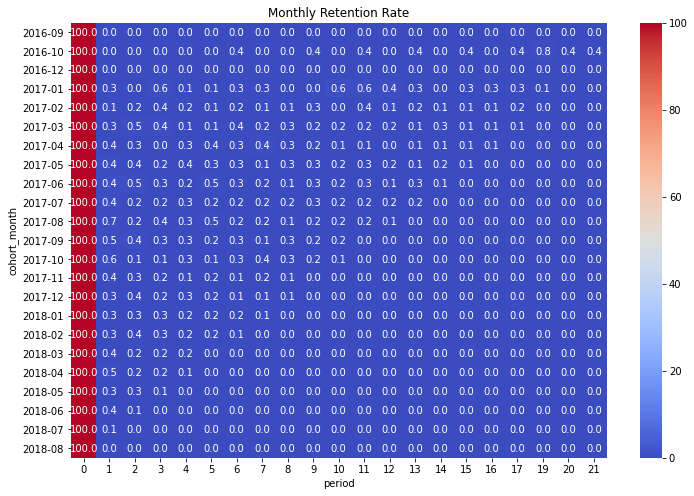

In [9]:
plt.figure(figsize=(12, 8))
plt.title("Monthly Retention Rate")
sns.heatmap(retention_rate, annot=True, fmt=".1f", cmap="coolwarm")
plt.show()

Как видно по карте, retention катастрофически мал, и составляет менее 1% за пределами уже первого месяца. Теперь решим оставшиеся подзадачи

In [10]:
# Расчитываем медианный retention 1-го месяца
median_retention_1month = retention_rate[1].median()
median_retention_1month

0.34987277353689566

In [11]:
# Находим когорту с самым высоким retention на 3-й месяц
best_cohort = retention_rate[3].idxmax()
best_cohort

Period('2017-01', 'M')

Задача 2. Определить, существует ли product/market fit у маркетплейса.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

PMF у данного продукта отсутствует. Retention крайне мал. Клиенты не задерживаются в нашем продукте. Продукт не удовлетворяет потребности наших клиентов. Наша первоначальная задача - сконцентрироваться на удержании клиентов.

Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

В первую очередь необходимо:

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Первая метрика должна отражать рост объёма продаж маркетплейса.
Вторая — показывать объем аудитории, которой продукт доставляет ценность.
Третья — отражать заинтересованность новых клиентов в продукте.
Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.
Пятая — отражать денежное выражение вовлеченности клиента.
Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно.

1. GMV (Gross Merchandise Value) — Общий объем продаж

Описание: Суммарная выручка от всех заказов на маркетплейсе.

In [12]:
# Объединяем данные о товарах в заказах с заказами и клиентами
data = pd.merge(data, items, on="order_id", how="left")

# GMV по месяцам (сумма price для всех успешных заказов(мы не получим дохода от недоставленных товаров))
monthly_gmv = data[data["order_status"] == "delivered"].resample("M", on="order_purchase_timestamp")["price"].sum()

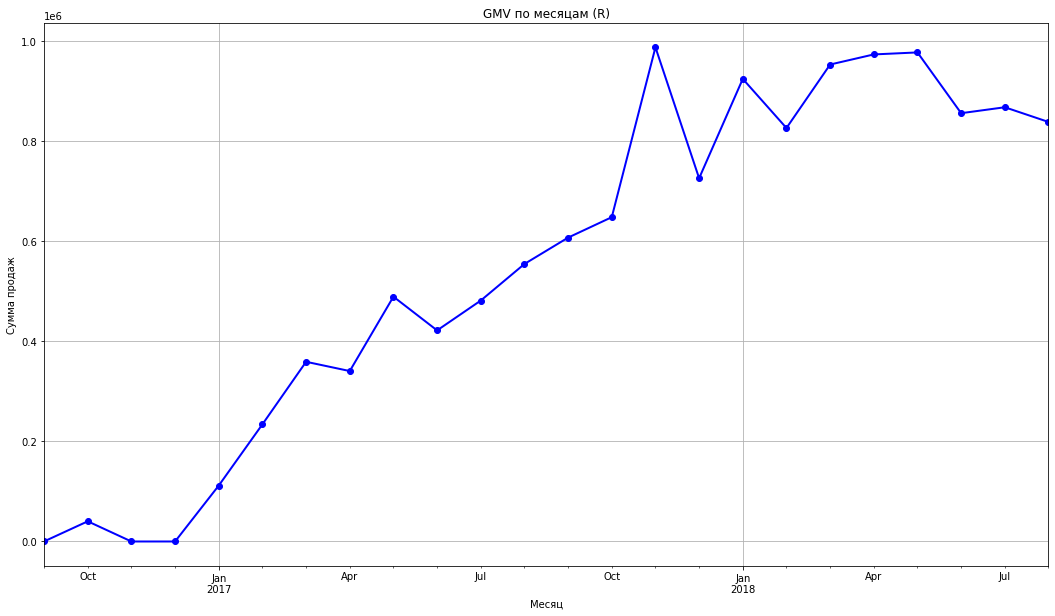

In [13]:
plt.figure(figsize=(18, 10))
monthly_gmv.plot(marker="o", color="blue", linewidth=2)
plt.title("GMV по месяцам (R)")
plt.xlabel("Месяц")
plt.ylabel("Сумма продаж")
plt.grid(True)
plt.show()

2. MAU (Monthly Active Users) — Ежемесячная активная аудитория

MAU = количество уникальных пользователей, совершивших хотя бы одну покупку в месяц.

In [14]:
monthly_mau = data[data["order_status"] == "delivered"].resample("M", on="order_purchase_timestamp")["customer_unique_id"].nunique()

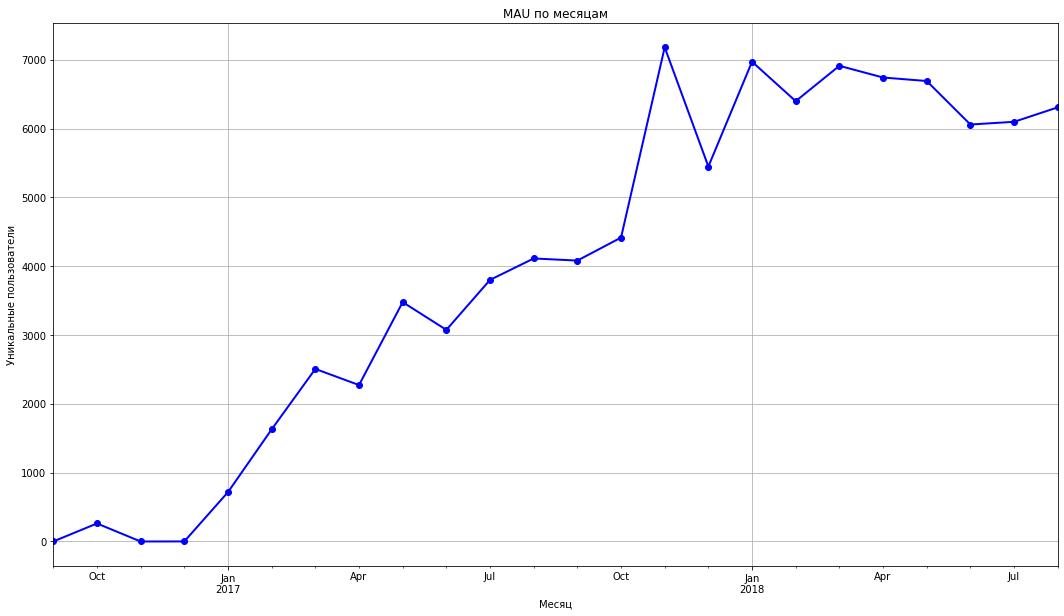

In [15]:
plt.figure(figsize=(18, 10))
monthly_mau.plot(marker="o", color="blue", linewidth=2)
plt.title("MAU по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Уникальные пользователи")
plt.grid(True)
plt.show()

3. Количество новых клиентов в месяц

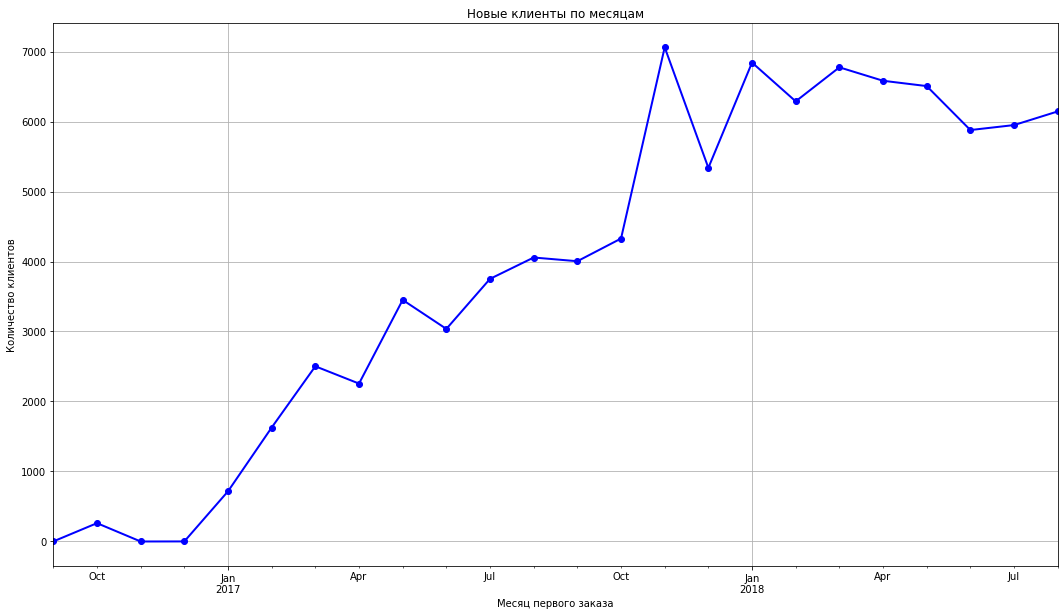

In [16]:
# Находим первый заказ каждого пользователя
first_purchases = data.groupby("customer_unique_id")["order_purchase_timestamp"].min().reset_index()
first_purchases.columns = ["customer_unique_id", "first_order_date"]

# Группируем по месяцу первого заказа (новые клиенты)
new_clients_monthly = first_purchases.resample("M", on="first_order_date").size()

# Визуализация
plt.figure(figsize=(18, 10))
new_clients_monthly.plot(marker="o", color="blue", linewidth=2)
plt.title("Новые клиенты по месяцам")
plt.xlabel("Месяц первого заказа")
plt.ylabel("Количество клиентов")
plt.grid(True)
plt.show()

4. Вовлеченность клиента в продолжение использования продукта - это Retention. Используем для рассчёта 30-дневный период

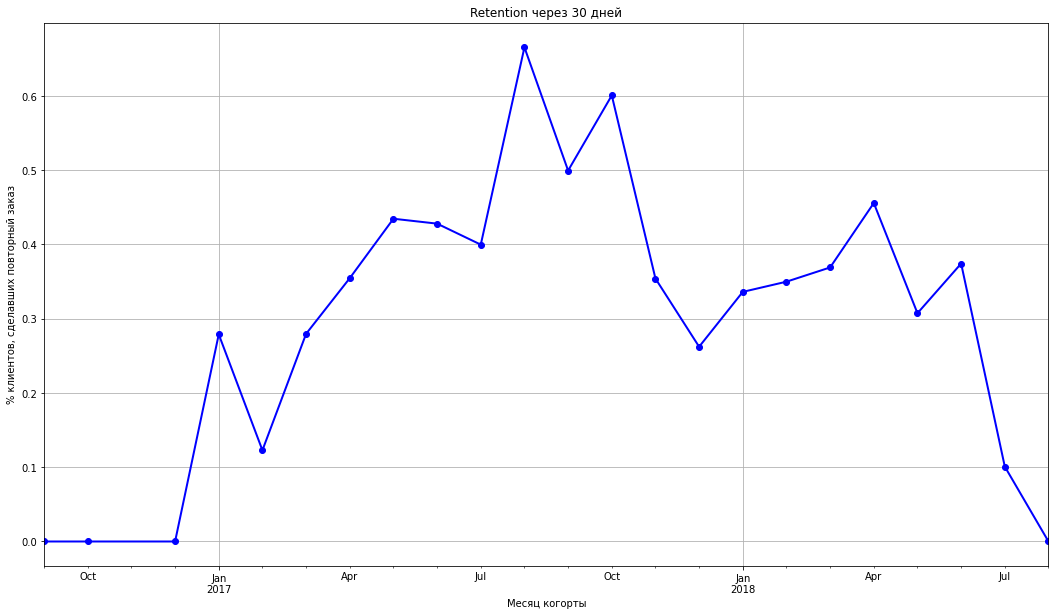

In [17]:
# Используем код из предыдущего ответа с 30-дневными периодами
plt.figure(figsize=(18, 10))
retention_rate[1].plot(marker="o", color="blue", linewidth=2)
plt.title("Retention через 30 дней")
plt.xlabel("Месяц когорты")
plt.ylabel("% клиентов, сделавших повторный заказ")
plt.grid(True)
plt.show()

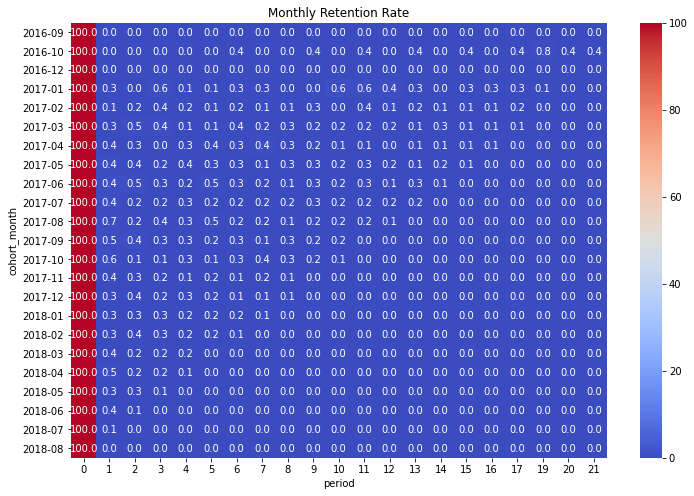

In [18]:
#Также можно продолжать использовать тепловую карту
plt.figure(figsize=(12, 8))
plt.title("Monthly Retention Rate")
sns.heatmap(retention_rate, annot=True, fmt=".1f", cmap="coolwarm")
plt.show()

 5. ARPU (Average Revenue Per User) — Средний доход на пользователя - денежное выражение вовлеченности клиента.
 
 ARPU = GMV / MAU

In [19]:
monthly_arpu = monthly_gmv / monthly_mau

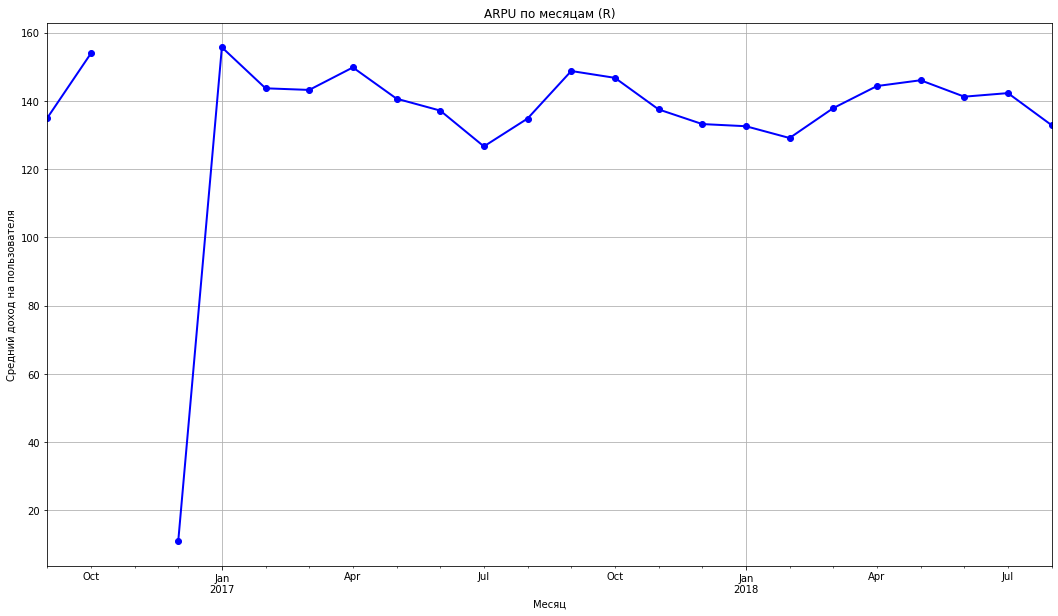

In [20]:

plt.figure(figsize=(18, 10))
monthly_arpu.plot(color="blue", marker="o", linewidth=2)
plt.title("ARPU по месяцам (R)")
plt.xlabel("Месяц")
plt.ylabel("Средний доход на пользователя")
plt.grid(True)
plt.show()

Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).


Гипотеза	
1. Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.	
2. Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, вследствие чего количество заказов увеличится за счёт повторных заказов.
3. Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при оформлении заказа, вследствие чего количество заказов увеличится за счёт повторных заказов.

Impact для первой гипотезы будет равен количеству отмен(cancelled и unavailable)

In [21]:
impact1 = orders[
    (orders['order_purchase_timestamp'] >= '2017-06-01') &
    (orders['order_status'].isin(['canceled', 'unavailable']))
]
impact1.nunique()

order_id                         974
customer_id                      974
order_status                       2
order_purchase_timestamp         972
order_approved_at                854
order_delivered_carrier_date      69
order_delivered_customer_date      1
order_estimated_delivery_date    277
dtype: int64

Количество таких заказов 974, присвоим impact, равный 5

Impact для второй гипотезы будет равен количеству уникальных покупателей, получивших заказ с запаздыванием, умноженному на конверсию

In [22]:
impact2 = data[
    (data['order_purchase_timestamp'] >= '2017-06-01') & 
    (data['order_status'] == 'delivered') & 
    (data['order_delivered_customer_date'] > data['order_estimated_delivery_date'])
]
impact2.nunique()

order_id                         7295
customer_id                      7295
order_status                        1
order_purchase_timestamp         7277
order_approved_at                7178
order_delivered_carrier_date     7006
order_delivered_customer_date    7287
order_estimated_delivery_date     293
customer_unique_id               7245
customer_zip_code_prefix         4554
customer_city                    1233
customer_state                     26
first_order_date                 7240
cohort_month                       20
days_since_first_order            113
period                             16
order_item_id                      21
product_id                       4782
seller_id                        1308
shipping_limit_date              7189
price                            1582
freight_value                    2458
dtype: int64

In [23]:
impact2.customer_unique_id.nunique()*median_retention_1month/100

25.34828244274809

Присвоим Impact, равный 1

Impact для третьей гипотезы будет равен количеству покупателей, совершивших только одну покупку, умноженному на конверсию

In [24]:
users = data[
    (data['order_purchase_timestamp'] >= '2017-06-01')].groupby("customer_unique_id").agg(order_count=("order_id", "nunique"))
impact3 = users[users["order_count"] == 1]
impact3.count()

order_count    80558
dtype: int64

In [25]:
impact3.count()*median_retention_1month/100

order_count    281.850509
dtype: float64

Присвоим Impact, равный 3

Теперь расчитаем ICE для всех гипотез: ICE = Impact * Ease * Confidence

In [26]:
ICE1 = 5*8*6
ICE1

240

In [27]:
ICE2 = 1*10*4
ICE2

40

In [28]:
ICE3 = 3*5*9
ICE3

135

Итак, выберем основной гипотезой первую: если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

Продакт попросил вас:

Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза.
Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail.

Возможные метрики

*Целевые*

Конверсия в доставленные заказы или объем продаж (должны увеличиться)

*Прокси*

Общее количество заказов (должно увеличиться)

*Барьерные*

Доля отменённых заказов, количество обращений в поддержку(должны уменьшиться)

Задача #6 

1.Проблема продукта: выручка маркетплейса стоит на месте уже несколько месяцев.

2.Описание выводов из пункта 1: Когортный анализ, выполненный с целью оценки месячного retention показал наличие проблемы, связанной с возвращаемостью клиентов. Retention для каждой когорты составляет менее 1%.

3.Описание выводов из пункта 2: PMF отсутствует. Пользователи обычно не возвращаются к маркетплейсу. Нужно решать данную проблему, масштабирование продукта приведёт только к убыткам

4.Описание выводов из пункта 3: Определены 5 основных метрик: GMV (Gross Merchandise Value) — Общий объем продаж; MAU (Monthly Active Users) — Ежемесячная активная аудитория; Количество новых клиентов в месяц; Retention; ARPU (Average Revenue Per User) — Средний доход на пользователя

5.Описание выводов из пункта 4: Согласно фреймворку ICE, была выбрана основной следущая гипотеза: если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

6.Описание выводов из пункта 5: Метрики, на которые должна повлиять выбранная вами гипотеза: конверсия в доставленные заказы, объем продаж, общее количество заказов (должны увеличиться), доля отменённых заказов, количество обращений в поддержку(должны уменьшиться)
